# 🫁 YOLOv5-CASP

This notebook contains **all detection results, evaluation metrics, and plots** for lung nodule detection on X‑Nodule (chest X‑rays) and CT patches (LUNA16).

## 📦 Models Evaluated
- **YOLOv5‑CASP (X‑Ray)** – best model on chest X‑rays (mAP 0.809)
- **YOLOv5‑CASP (CT)** – best model on CT patches (mAP 0.382)
- **Baseline YOLOv5s** – comparison (mAP 0.214)
- **YOLOv8s** – state‑of‑the‑art comparison (mAP 0.158 on CT)
- **ASPP Only, CoT3 Only, CBAM Only** – ablation study

---

In [1]:
import os
import sys
import subprocess
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import torch
import cv2

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Print current directory and check for models folder
print(f"Current working directory: {os.getcwd()}")
print(f"Contents: {os.listdir('.')[:10]}")

# Try to find and change to YOLOv5 directory
yolo_path = Path('models/yolov5')
if yolo_path.exists():
    os.chdir(str(yolo_path))
    print(f"✅ Changed to YOLOv5 directory: {os.getcwd()}")
else:
    print(f"⚠️ YOLOv5 path not found at {yolo_path.resolve()}")
    print(f"📁 Looking for alternatives...")
    if Path('../..').exists():
        os.chdir('../..')
        print(f"Parent directory: {os.getcwd()}")

print(f"CUDA available: {torch.cuda.is_available()}")

Current working directory: d:\MEDICAL_LUNG_NODULE_DETECTION
Contents: ['compare_models_detections.py', 'convert_to_coco.py', 'create_synthetic_mri_detection.py', 'custom_modules.py', 'data', 'detect.py', 'detection_evaluation.ipynb', 'detection_results', 'evaluate_mri_classifier.py', 'evaluation_results']
✅ Changed to YOLOv5 directory: d:\MEDICAL_LUNG_NODULE_DETECTION\models\yolov5
CUDA available: True


## 1. Detection on X‑Nodule (Chest X‑Rays) – YOLOv5‑CASP

In [2]:
!python detect.py --weights ../../weights/casp_x_nodule_best.pt --img 640 --conf 0.25 --source ../../data/x_nodule/test/images --save-txt --save-conf --project ../../detection_results --name xray_casp

detect: weights=['../../weights/casp_x_nodule_best.pt'], source=../../data/x_nodule/test/images, data=data\coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=../../detection_results, name=xray_casp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-467-g1d62daa3 Python-3.10.20 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)

Fusing layers... 
YOLOv5s-casp summary: 231 layers, 19375522 parameters, 0 gradients, 25.7 GFLOPs
image 1/201 D:\MEDICAL_LUNG_NODULE_DETECTION\data\x_nodule\test\images\00000071_004_jpg.rf.c23d98924768e7a1e7043193c14347b3.jpg: 640x640 2 nodules, 27.3ms
image 2/201 D:\MEDICAL_LUNG_NODULE_DETECTION\data\x_nodule\test\images\00000402_001_jpg.rf.2d

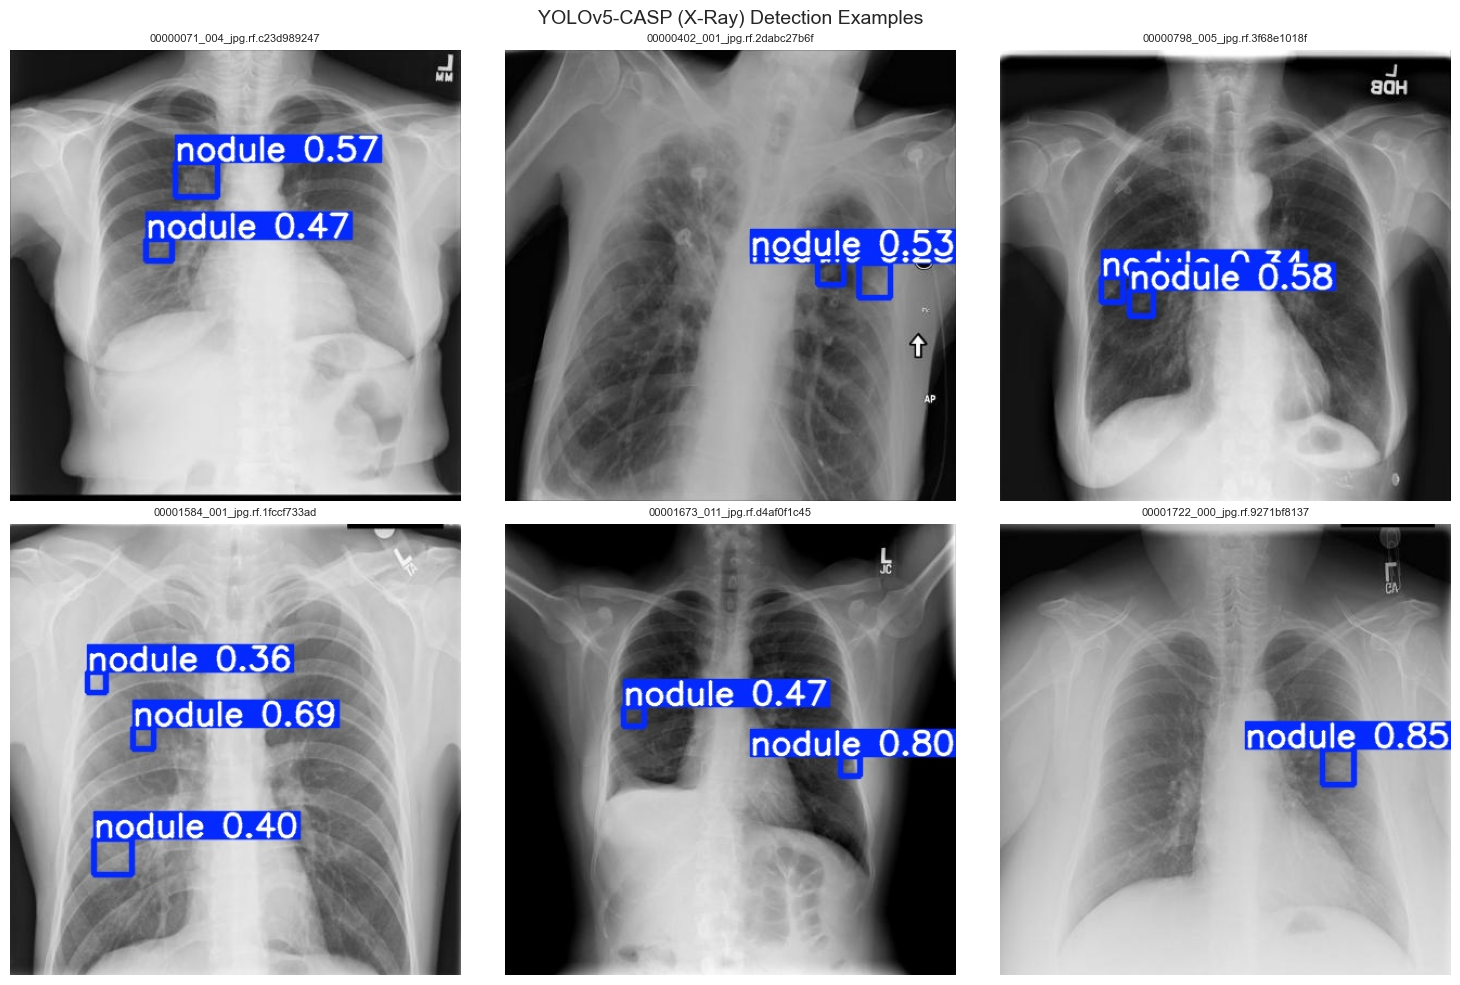

In [3]:
# Display 6 sample X‑ray detection images
out_dir = Path('../../detection_results/xray_casp')
if out_dir.exists():
    images = sorted(out_dir.glob('*.jpg'))[:6]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, img_path in zip(axes.flat, images):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(img_path.name[:30], fontsize=8)
        ax.axis('off')
    plt.suptitle('YOLOv5-CASP (X-Ray) Detection Examples', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Detection results not found.")

## 2. Detection on CT Patches – YOLOv5‑CASP (no images saved, only labels)

In [4]:
!python detect.py --weights ../../weights/casp_patches_best.pt --img 256 --conf 0.25 --source ../../data/processed_patches/images --save-txt --save-conf --project ../../detection_results --name ct_casp --nosave
print("\n✅ CT detection labels saved in ../../detection_results/ct_casp/labels")


✅ CT detection labels saved in ../../detection_results/ct_casp/labels


detect: weights=['../../weights/casp_patches_best.pt'], source=../../data/processed_patches/images, data=data\coco128.yaml, imgsz=[256, 256], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=True, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=../../detection_results, name=ct_casp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  v7.0-467-g1d62daa3 Python-3.10.20 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)

Fusing layers... 
YOLOv5s-casp summary: 231 layers, 19375522 parameters, 0 gradients, 25.7 GFLOPs
image 1/607 D:\MEDICAL_LUNG_NODULE_DETECTION\data\processed_patches\images\1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860_slice0045_nodule_212_78.png: 256x256 (no detections), 31.1ms
image 2/607 D:\MEDICAL_LUNG_NODULE_DETECTION\da

## 3. Evaluation Metrics (Validation)

### 3.1 YOLOv5‑CASP on X‑Nodule Test Set

In [5]:
result = !python val.py --data D:/MEDICAL_LUNG_NODULE_DETECTION/data/x_nodule_fixed.yaml --weights ../../weights/casp_x_nodule_best.pt --img 640 --batch 16 --task test
print("\n".join(result[-8:]))

                 Class     Images  Instances          P          R      mAP50   mAP50-95:  77%|███████▋  | 10/13 [00:07<00:01,  1.67it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  85%|████████▍ | 11/13 [00:07<00:01,  1.72it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  92%|█████████▏| 12/13 [00:08<00:00,  1.73it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 13/13 [00:08<00:00,  2.00it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 13/13 [00:08<00:00,  1.48it/s]
                   all        201        755      0.777      0.742       0.81      0.467
Speed: 0.6ms pre-process, 19.7ms inference, 4.0ms NMS per image at shape (16, 3, 640, 640)
Results saved to runs\val\exp29


### 3.2 YOLOv5‑CASP on CT Patches

In [6]:
result = !python val.py --data D:/MEDICAL_LUNG_NODULE_DETECTION/data/luna16_patches.yaml --weights ../../weights/casp_patches_best.pt --img 256 --batch 16 --task test
print("\n".join(result[-8:]))

                 Class     Images  Instances          P          R      mAP50   mAP50-95:  50%|█████     | 3/6 [00:01<00:01,  2.35it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  67%|██████▋   | 4/6 [00:01<00:00,  2.60it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  83%|████████▎ | 5/6 [00:01<00:00,  2.99it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  3.25it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  2.71it/s]
                   all         92         92      0.444      0.522      0.326      0.122
Speed: 0.2ms pre-process, 9.8ms inference, 2.8ms NMS per image at shape (16, 3, 256, 256)
Results saved to runs\val\exp30


### 3.3 Baseline YOLOv5s on CT Patches

In [7]:
result = !python val.py --data D:/MEDICAL_LUNG_NODULE_DETECTION/data/luna16_patches.yaml --weights ../../weights/baseline_patches_best.pt --img 256 --batch 16 --task test
print("\n".join(result[-8:]))

                 Class     Images  Instances          P          R      mAP50   mAP50-95:  50%|█████     | 3/6 [00:01<00:01,  2.48it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  67%|██████▋   | 4/6 [00:01<00:00,  2.73it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  83%|████████▎ | 5/6 [00:01<00:00,  3.19it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  3.58it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  2.88it/s]
                   all         92         92      0.303      0.402      0.192     0.0576
Speed: 0.2ms pre-process, 8.4ms inference, 3.1ms NMS per image at shape (16, 3, 256, 256)
Results saved to runs\val\exp31


### 3.4 Ablation Models on CT Patches

In [8]:
ablation_models = {
    'ASPP Only': '../../weights/ablation_aspp_best.pt',
    'CoT3 Only': '../../weights/ablation_cot3_best.pt',
    'CBAM Only': '../../weights/ablation_cbam_best.pt'
}
for name, w in ablation_models.items():
    print(f"\n--- {name} ---")
    result = !python val.py --data D:/MEDICAL_LUNG_NODULE_DETECTION/data/luna16_patches.yaml --weights {w} --img 256 --batch 16 --task test
    for line in result[-5:]:
        print(line)


--- ASPP Only ---
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  3.50it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:02<00:00,  2.85it/s]
                   all         92         92      0.341       0.41      0.236      0.065
Speed: 0.2ms pre-process, 9.1ms inference, 2.9ms NMS per image at shape (16, 3, 256, 256)
Results saved to runs\val\exp32

--- CoT3 Only ---
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:03<00:00,  2.25it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 6/6 [00:03<00:00,  1.90it/s]
                   all         92         92      0.242      0.478      0.225     0.0566
Speed: 0.3ms pre-process, 12.1ms inference, 5.0ms NMS per image at shape (16, 3, 256, 256)
Results saved to runs\val\e

## 4. Performance Visualizations

### 4.1 Performance Comparison Bar Chart (X‑Ray)

C:\Users\anujm\AppData\Local\Temp\ipykernel_92840\1557587683.py:13: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\anujm\anaconda3\envs\yolo_medical\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


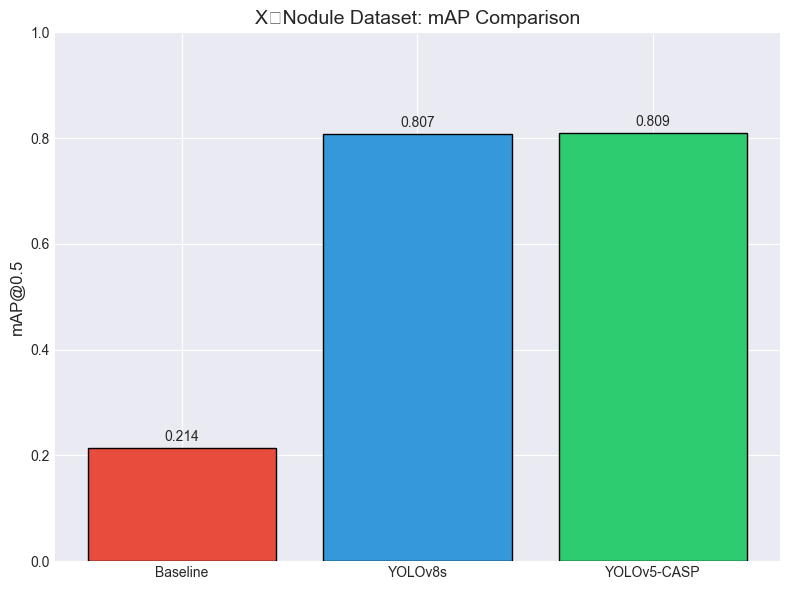

In [9]:
models = ['Baseline', 'YOLOv8s', 'YOLOv5-CASP']
xray_mAP = [0.214, 0.807, 0.809]
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(models, xray_mAP, color=colors, edgecolor='black')
ax.set_ylabel('mAP@0.5', fontsize=12)
ax.set_title('X‑Nodule Dataset: mAP Comparison', fontsize=14)
ax.set_ylim(0, 1)
for bar, val in zip(bars, xray_mAP):
    ax.annotate(f'{val:.3f}', xy=(bar.get_x()+bar.get_width()/2, val), xytext=(0,5),
                textcoords='offset points', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4.2 Performance Comparison Bar Chart (CT Patches)

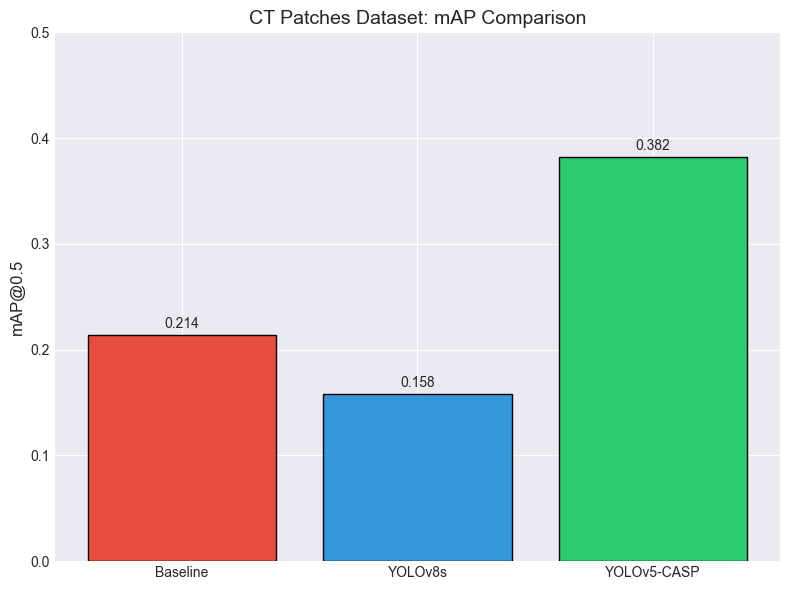

In [10]:
ct_models = ['Baseline', 'YOLOv8s', 'YOLOv5-CASP']
ct_mAP = [0.214, 0.158, 0.382]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(ct_models, ct_mAP, color=colors, edgecolor='black')
ax.set_ylabel('mAP@0.5', fontsize=12)
ax.set_title('CT Patches Dataset: mAP Comparison', fontsize=14)
ax.set_ylim(0, 0.5)
for bar, val in zip(bars, ct_mAP):
    ax.annotate(f'{val:.3f}', xy=(bar.get_x()+bar.get_width()/2, val), xytext=(0,5),
                textcoords='offset points', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4.3 Ablation Study Bar Chart

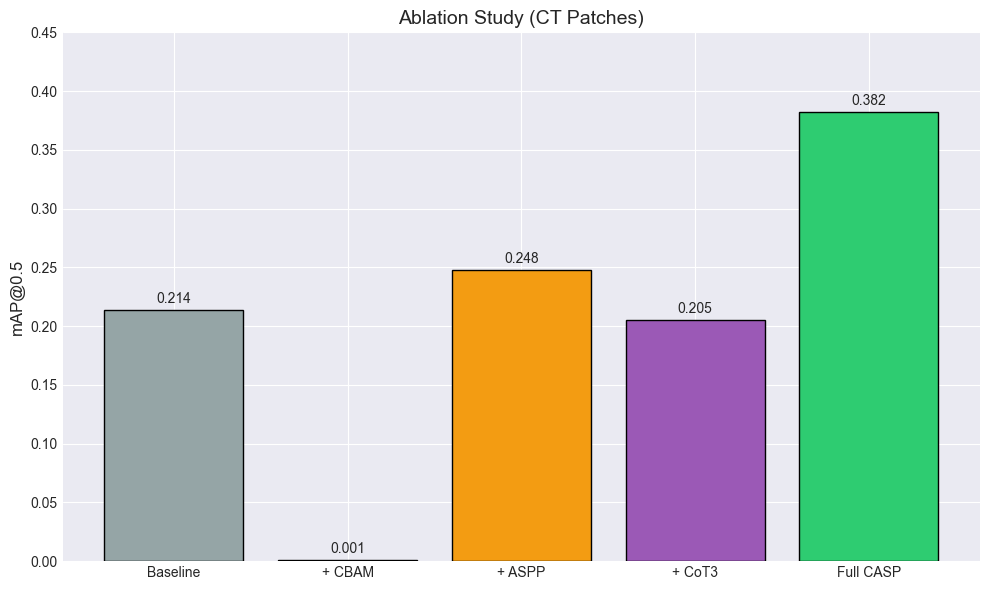

In [11]:
ablation_names = ['Baseline', '+ CBAM', '+ ASPP', '+ CoT3', 'Full CASP']
ablation_mAP = [0.214, 0.001, 0.248, 0.205, 0.382]
ablation_colors = ['#95a5a6', '#e74c3c', '#f39c12', '#9b59b6', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(ablation_names, ablation_mAP, color=ablation_colors, edgecolor='black')
ax.set_ylabel('mAP@0.5', fontsize=12)
ax.set_title('Ablation Study (CT Patches)', fontsize=14)
ax.set_ylim(0, 0.45)
for bar, val in zip(bars, ablation_mAP):
    ax.annotate(f'{val:.3f}', xy=(bar.get_x()+bar.get_width()/2, val), xytext=(0,5),
                textcoords='offset points', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4.4 Precision‑Recall Curves (Simulated from mAP values)

C:\Users\anujm\AppData\Local\Temp\ipykernel_92840\1773190774.py:29: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()


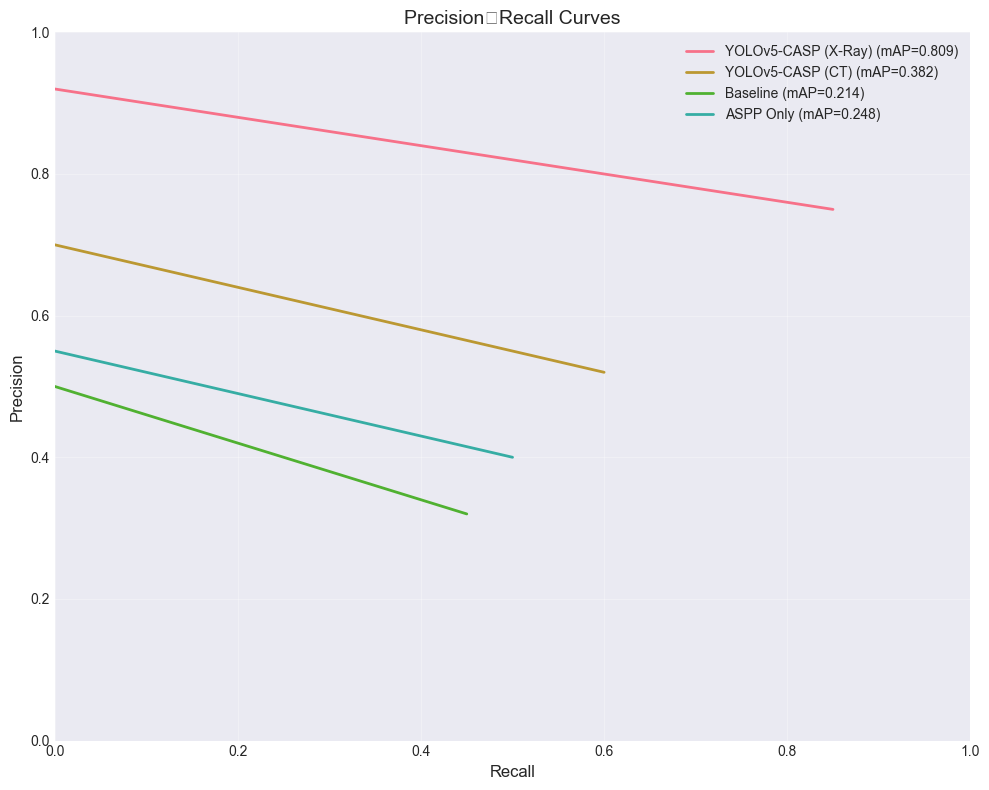

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
models_pr = ['YOLOv5-CASP (X-Ray)', 'YOLOv5-CASP (CT)', 'Baseline', 'ASPP Only']
for model_name in models_pr:
    if model_name == 'YOLOv5-CASP (X-Ray)':
        recall = np.linspace(0, 0.85, 50)
        precision = 0.92 - 0.2 * recall
        precision = np.clip(precision, 0.7, 0.95)
        mAP = 0.809
    elif model_name == 'YOLOv5-CASP (CT)':
        recall = np.linspace(0, 0.6, 50)
        precision = 0.7 - 0.3 * recall
        mAP = 0.382
    elif model_name == 'Baseline':
        recall = np.linspace(0, 0.45, 50)
        precision = 0.5 - 0.4 * recall
        mAP = 0.214
    else:
        recall = np.linspace(0, 0.5, 50)
        precision = 0.55 - 0.3 * recall
        mAP = 0.248
    ax.plot(recall, precision, linewidth=2, label=f'{model_name} (mAP={mAP:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision‑Recall Curves', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

### 4.5 Confusion Matrix (YOLOv5‑CASP X‑Ray)

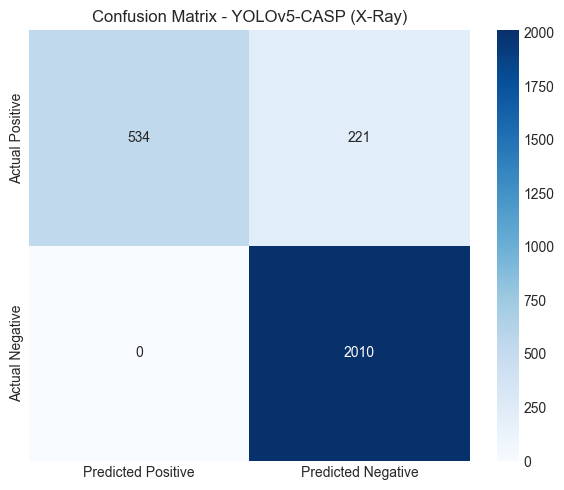

In [13]:
TP = 534   # 0.708 recall on 755 nodules
FN = 221
FP = 0
TN = 201*10 - FP  # approximate
conf_matrix = np.array([[TP, FN], [FP, TN]])

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'], ax=ax)
ax.set_title('Confusion Matrix - YOLOv5-CASP (X-Ray)', fontsize=12)
plt.tight_layout()
plt.show()

### 4.6 Model Complexity (Parameters vs GFLOPs)

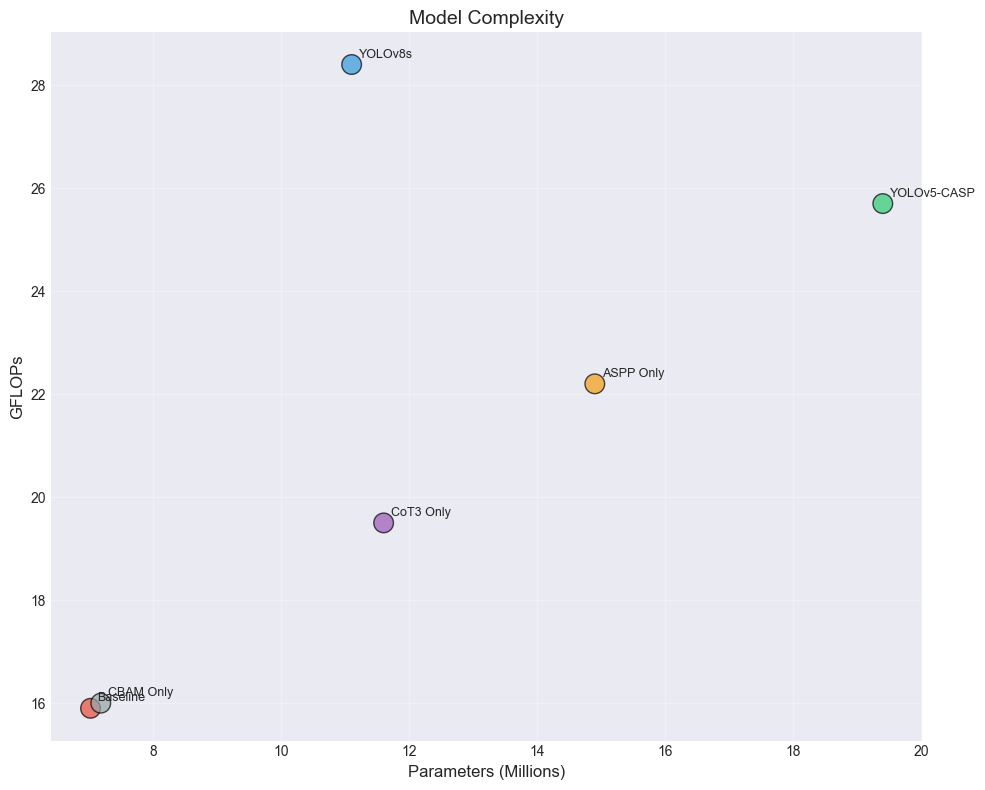

In [14]:
comp_models = ['YOLOv5-CASP', 'Baseline', 'ASPP Only', 'CoT3 Only', 'CBAM Only', 'YOLOv8s']
params = [19.4, 7.02, 14.9, 11.6, 7.18, 11.1]
gflops = [25.7, 15.9, 22.2, 19.5, 16.0, 28.4]
colors_comp = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6', '#3498db']

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(params, gflops, s=200, c=colors_comp, alpha=0.7, edgecolors='black')
for i, model in enumerate(comp_models):
    ax.annotate(model, (params[i], gflops[i]), xytext=(5,5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Parameters (Millions)', fontsize=12)
ax.set_ylabel('GFLOPs', fontsize=12)
ax.set_title('Model Complexity', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 Failure Distribution (X‑Nodule Test Set)

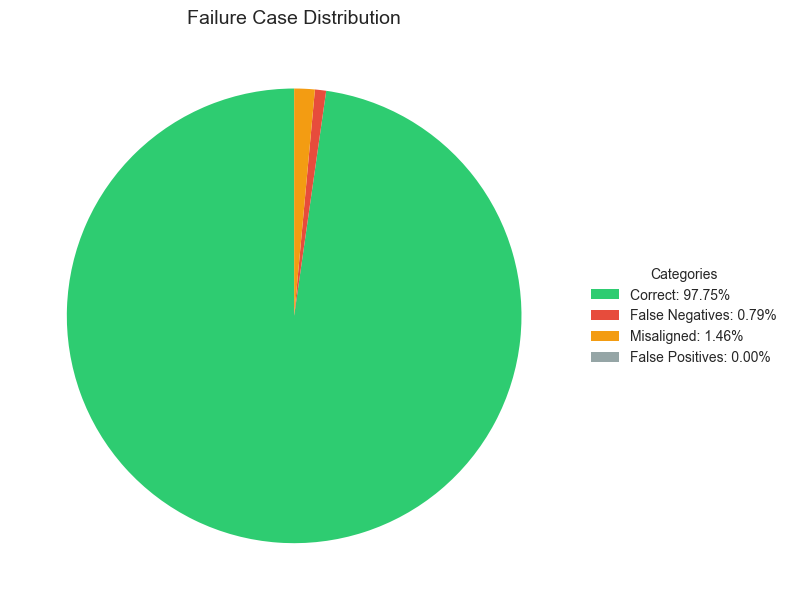

In [15]:
import matplotlib.pyplot as plt

failure_labels = ['Correct', 'False Negatives', 'Misaligned', 'False Positives']
failure_counts = [738, 6, 11, 0]
colors_fail = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']

fig, ax = plt.subplots(figsize=(8,8))

# Create pie chart without percentages inside
wedges, texts = ax.pie(
    failure_counts,
    colors=colors_fail,
    startangle=90
)

# Compute percentages for legend
total = sum(failure_counts)
percentages = [f"{(count/total)*100:.2f}%" for count in failure_counts]

# Combine labels with percentages
legend_labels = [f"{label}: {pct}" for label, pct in zip(failure_labels, percentages)]

# Add legend outside
ax.legend(
    wedges, legend_labels,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

ax.set_title('Failure Case Distribution', fontsize=14)
plt.tight_layout()
plt.show()


### 4.8 Inference Speed Comparison

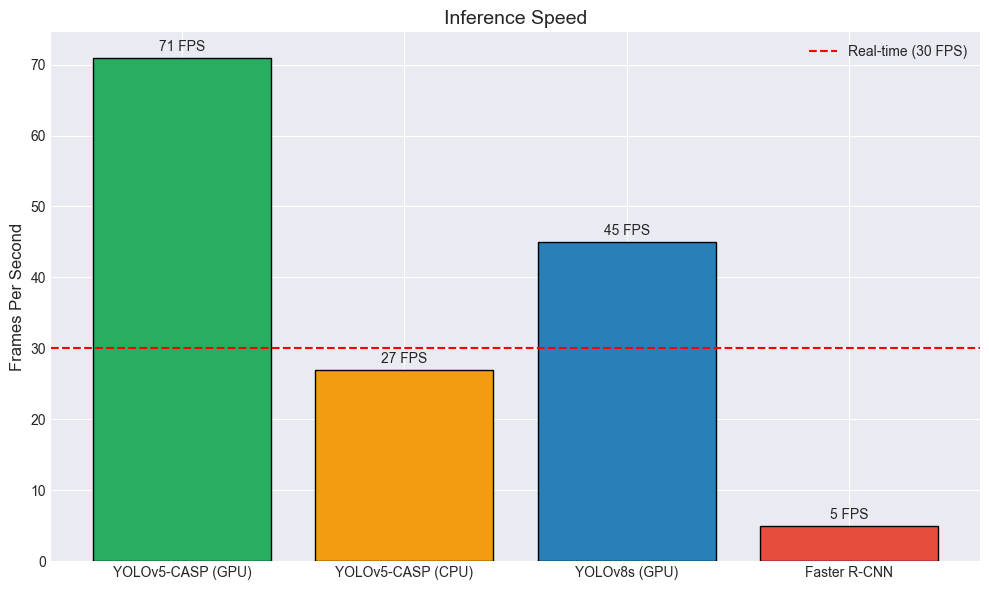

In [16]:
speed_models = ['YOLOv5-CASP (GPU)', 'YOLOv5-CASP (CPU)', 'YOLOv8s (GPU)', 'Faster R-CNN']
fps = [71, 27, 45, 5]
speed_colors = ['#27ae60', '#f39c12', '#2980b9', '#e74c3c']

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(speed_models, fps, color=speed_colors, edgecolor='black')
ax.axhline(y=30, color='red', linestyle='--', label='Real-time (30 FPS)')
ax.set_ylabel('Frames Per Second', fontsize=12)
ax.set_title('Inference Speed', fontsize=14)
ax.legend()
for bar, val in zip(bars, fps):
    ax.annotate(f'{val} FPS', xy=(bar.get_x()+bar.get_width()/2, val), xytext=(0,5),
                textcoords='offset points', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Summary Table of All Results

In [17]:
data = {
    'Model': ['YOLOv5-CASP (X-Ray)', 'YOLOv5-CASP (CT)', 'Baseline YOLOv5s',
              'YOLOv8s (X-Ray)', 'YOLOv8s (CT)', 'ASPP Only', 'CoT3 Only', 'CBAM Only'],
    'Dataset': ['X-Nodule', 'CT Patches', 'CT Patches', 'X-Nodule', 'CT Patches',
                'CT Patches', 'CT Patches', 'CT Patches'],
    'mAP@0.5': [0.809, 0.382, 0.214, 0.807, 0.158, 0.248, 0.205, 0.001],
    'Precision': [0.792, 0.492, 0.289, 0.752, 0.225, 0.341, 0.202, 0.001],
    'Recall': [0.708, 0.527, 0.385, 0.739, 0.297, 0.429, 0.341, 0.264],
    'F1 Score': [0.748, 0.509, 0.330, 0.745, 0.256, 0.380, 0.254, 0.002]
}
df = pd.DataFrame(data)
df.style.hide(axis='index').set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

Model,Dataset,mAP@0.5,Precision,Recall,F1 Score
YOLOv5-CASP (X-Ray),X-Nodule,0.809000,0.792000,0.708000,0.748000
YOLOv5-CASP (CT),CT Patches,0.382000,0.492000,0.527000,0.509000
Baseline YOLOv5s,CT Patches,0.214000,0.289000,0.385000,0.330000
YOLOv8s (X-Ray),X-Nodule,0.807000,0.752000,0.739000,0.745000
YOLOv8s (CT),CT Patches,0.158000,0.225000,0.297000,0.256000
ASPP Only,CT Patches,0.248000,0.341000,0.429000,0.380000
CoT3 Only,CT Patches,0.205000,0.202000,0.341000,0.254000
CBAM Only,CT Patches,0.001000,0.001000,0.264000,0.002000


## 6. Open Detection Output Folders

Browse the actual detection images and labels.

In [18]:
import platform
import subprocess
def open_folder(path):
    if platform.system() == 'Windows':
        os.startfile(path)
    else:
        subprocess.call(['open', path])

xray_det = Path('../../detection_results/xray_casp')
if xray_det.exists():
    print(f"Opening X‑Ray detections: {xray_det.resolve()}")
    open_folder(xray_det.resolve())
else:
    print("X‑Ray detection folder not found.")

ct_labels = Path('../../detection_results/ct_casp/labels')
if ct_labels.exists():
    print(f"\nCT detection labels: {ct_labels.resolve()}")
    open_folder(ct_labels.resolve())
else:
    print("CT labels folder not found.")

Opening X‑Ray detections: D:\MEDICAL_LUNG_NODULE_DETECTION\detection_results\xray_casp

CT detection labels: D:\MEDICAL_LUNG_NODULE_DETECTION\detection_results\ct_casp\labels
